# 04 — Evaluation, Explainability & Business Impact
**Customer Churn Intelligence System**

Goal: go beyond accuracy. This notebook explains *why* the model flags a customer as at-risk (SHAP), and converts predictions into a business-facing retention report — the part most churn projects skip entirely.

In [1]:
import sys
from pathlib import Path
import os

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import shap

sys.path.append(str(Path.cwd().parent))
os.chdir(Path.cwd().parent)
from src.utils.config import load_config
from src.models.evaluate_model import business_retention_report

config = load_config()

## Load the trained model + processed data

In [2]:
bundle = joblib.load(config['model']['saved_model_path'])
model, features, name = bundle['model'], bundle['features'], bundle['name']
print(f'Loaded model: {name}')

df = pd.read_csv(config['data']['processed_path'])
df[features].head()

Loaded model: random_forest


,gender,senior_citizen,partner,dependents,tenure,contract,internet_service,tech_support,online_security,paperless_billing,payment_method,monthly_charges,total_charges,num_support_calls,sentiment_polarity,frustration_score,topic_billing,topic_service,topic_leaving
0,1,0,0,0,6,0,1,0,1,0,3,19.35,125.36,1,1.000000,0.000000,0,0,0
1,0,0,1,0,56,1,1,1,0,1,3,49.27,2761.10,0,0.000000,0.500000,1,0,0
2,1,0,0,0,47,2,0,1,0,0,1,40.27,1690.22,1,1.000000,0.000000,0,0,0
3,1,0,1,0,32,2,1,1,0,1,1,67.95,1967.49,2,-0.483333,0.741667,0,1,0
4,1,0,0,0,31,0,1,0,2,1,0,45.31,1343.86,1,1.000000,0.000000,0,0,0


## Explainability — SHAP feature importance
Instead of treating the model as a black box, SHAP tells us *how much* each feature pushed a prediction toward 'will churn' vs 'will stay'. This is the difference between a model a business can trust and one it can't.

In [3]:
sample = df[features].sample(min(150, len(df)), random_state=42)
explainer = shap.Explainer(model.predict, sample)
shap_values = explainer(sample)

Background dataset has 150 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=150 when initializing the masker.


PermutationExplainer explainer:   3%|▎         | 4/150 [00:00<?, ?it/s]

PermutationExplainer explainer:   4%|▍         | 6/150 [00:10<00:41,  3.46it/s]

PermutationExplainer explainer:   5%|▍         | 7/150 [00:11<00:59,  2.40it/s]

PermutationExplainer explainer:   5%|▌         | 8/150 [00:12<01:08,  2.08it/s]

...

PermutationExplainer explainer:  99%|█████████▊| 148/150 [01:36<00:01,  1.61it/s]

PermutationExplainer explainer:  99%|█████████▉| 149/150 [01:36<00:00,  1.62it/s]

PermutationExplainer explainer: 100%|██████████| 150/150 [01:37<00:00,  1.63it/s]

PermutationExplainer explainer: 151it [01:38,  1.64it/s]                         

PermutationExplainer explainer: 151it [01:38,  1.50it/s]

/tmp/ipykernel_616/208249662.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, sample, show=True)


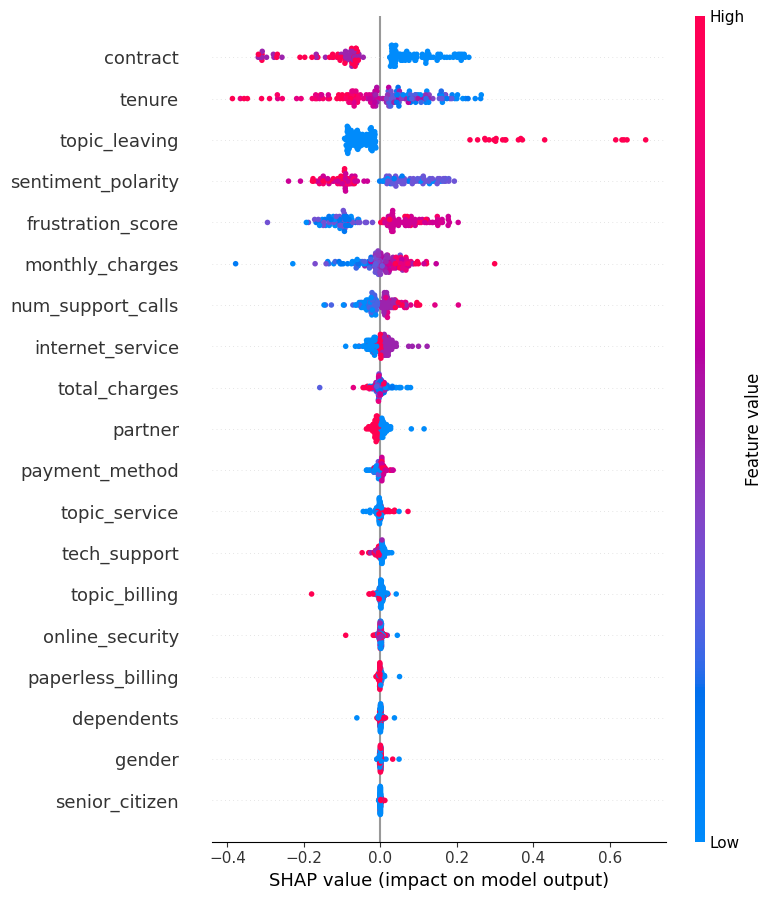

In [4]:
shap.summary_plot(shap_values, sample, show=True)

**How to read this:** features at the top have the biggest overall impact on churn predictions. Red points pushing right mean that feature value increases churn risk for that customer; blue points pushing left mean it decreases risk.

## Business layer — from probability to action
A churn probability alone isn't actionable. We convert it into:
- **expected_revenue_at_risk** — annual revenue we stand to lose from this customer
- **campaign_expected_savings** — expected net savings *if* we run a retention campaign on them, net of campaign cost

In [5]:
retention_df = business_retention_report(df, model, features, config)
retention_df.sort_values('churn_probability', ascending=False).head(10)

,customer_id,churn_probability,expected_revenue_at_risk,campaign_expected_savings
1738,CUST-01738,0.955065,744.950924,248.732823
1266,CUST-01266,0.951495,742.165716,247.758001
1239,CUST-01239,0.947379,738.955934,246.634577
3527,CUST-03527,0.942293,734.988877,245.246107
2338,CUST-02338,0.938070,731.694966,244.093238
3673,CUST-03673,0.933231,727.919976,242.771992
3504,CUST-03504,0.931419,726.507158,242.277505
4303,CUST-04303,0.931234,726.362855,242.226999
1408,CUST-01408,0.929921,725.338621,241.868517
517,CUST-00517,0.925916,722.214782,240.775174


## Top 20 customers to prioritize for retention outreach

In [6]:
top20 = retention_df.sort_values('churn_probability', ascending=False).head(20)
top20

,customer_id,churn_probability,expected_revenue_at_risk,campaign_expected_savings
1738,CUST-01738,0.955065,744.950924,248.732823
1266,CUST-01266,0.951495,742.165716,247.758001
1239,CUST-01239,0.947379,738.955934,246.634577
3527,CUST-03527,0.942293,734.988877,245.246107
2338,CUST-02338,0.938070,731.694966,244.093238
3673,CUST-03673,0.933231,727.919976,242.771992
3504,CUST-03504,0.931419,726.507158,242.277505
4303,CUST-04303,0.931234,726.362855,242.226999
1408,CUST-01408,0.929921,725.338621,241.868517
517,CUST-00517,0.925916,722.214782,240.775174


## Estimated business impact of a targeted campaign

In [7]:
total_savings = retention_df[retention_df['campaign_expected_savings'] > 0]['campaign_expected_savings'].sum()
print(f'Estimated annual savings from a targeted retention campaign: ${total_savings:,.2f}')

Estimated annual savings from a targeted retention campaign: $439,360.01


## Conclusion
This system doesn't just predict churn — it explains *why* (SHAP), and translates that into a *ranked action list* with an *estimated dollar impact*. That's the gap between a typical ML portfolio notebook and a production-style decision-support system, and it's the core idea behind this project.